# Notebook 00: Business Understanding & Modeling Framework
## FreshRetailNet-50K: How to Think About Demand Forecasting & Inventory Optimization

---

**Purpose**: Before writing any code, you need to understand *what problem you're solving*, *what data you have*, and *how to model it correctly*. This notebook is the conceptual foundation for everything that follows.

**Who is this for?**
- Business stakeholders who want to understand the modeling approach
- Data scientists starting a new demand forecasting / inventory optimization project
- Anyone who wants the "big picture" before diving into implementation

**What this notebook covers:**

| Section | Topic | Key Question |
|---------|-------|--------------|
| 1 | The Business Problem | What decision are we trying to improve? |
| 2 | What Data Do We Have? | What columns exist and what role does each play? |
| 3 | Sales ≠ Demand | Why can't we trust the sales numbers? |
| 4 | Train vs Test | What do we actually know — and what don't we? |
| 5 | Modeling Forecasting | How do we predict future demand? |
| 6 | Modeling Optimization | How do we turn forecasts into order decisions? |
| 7 | Where to Focus Effort | Which products deserve ML and which don't? |
| 8 | Validating Forecasts | How do we know our predictions are good? |
| 9 | Validating Optimization | The hard problem — evaluating without ground truth |
| 10 | The Modeling Roadmap | Putting it all together |

> **Note**: This notebook is intentionally light on code and heavy on concepts. Notebooks 01–05 provide the hands-on implementation.

In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings, os

NB_OUT = os.path.join('..', 'notebook_output')
os.makedirs(NB_OUT, exist_ok=True)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

print('Libraries loaded.')

Libraries loaded.


---
## Section 1: The Business Problem

### The Daily Decision

Every morning, a fresh retail company must answer one question for every product in every store:

> **"How many kilograms should we order today?"**

This seems simple, but it's one of the hardest problems in retail operations. The answer depends on:

1. **How much will customers want?** (demand forecasting)
2. **How much should we stock, given that we're uncertain?** (inventory optimization)

### Why Perishables Are Harder

For durable goods (electronics, clothing), overstock is inconvenient but not catastrophic — unsold inventory can wait. For **perishable goods** (fresh produce, meat, dairy, seafood), overstock is **destruction**:

| Scenario | Durable Goods | Perishable Goods |
|----------|--------------|-----------------|
| **Order too much** | Inventory sits on shelf → holding cost | Product expires → **total loss** (waste) |
| **Order too little** | Customer waits or buys later | Customer leaves → **lost sale + lost trust** |
| **Correction time** | Can adjust next quarter | Must adjust **tomorrow** |
| **Shelf life** | Months to years | **1–3 days** |

This asymmetry makes the problem urgent and the cost of errors high.

### The Two-Step Solution

Our approach decomposes the problem into two sequential steps:

| Step | Question | Method | Output |
|------|----------|--------|--------|
| **1. Forecast** | "How much will customers want?" | Machine learning (LightGBM ensemble) | Predicted demand (kg) per store-product per day |
| **2. Optimize** | "How much should we order?" | Newsvendor theory + inventory policies | Order quantity Q (kg) per store-product per day |

Step 2 is **not** "just order whatever the forecast says." The forecast gives you the *expected* demand, but real demand is uncertain. The optimization step accounts for this uncertainty by choosing an order quantity that balances the cost of ordering too much against the cost of ordering too little.

> **Key Insight**: A perfect forecast with a bad inventory policy will underperform a decent forecast with a good inventory policy. Both steps matter.

### How This Maps to the Notebook Series

| Business Question | Pipeline Stage | Notebook |
|-------------------|---------------|----------|
| What does our data look like? What patterns exist? | Data Exploration | **NB 01** |
| How do we handle stockout-censored data? | Censored Demand Recovery | **NB 01** |
| What inputs does the model need? | Feature Engineering | **NB 02** |
| How do we train and validate the forecast? | Model Training & CV | **NB 03** |
| How accurate is the forecast? Where does it fail? | Forecast Evaluation | **NB 04** |
| How do we turn forecasts into orders? | Inventory Optimization | **NB 05** |
| Which products need ML vs. simple rules? | ABC-XYZ Segmentation | **NB 05** |

This notebook (NB 00) provides the **conceptual framework** that ties all of these together.

---
## Section 2: What Data Do We Have?

Let's look at the raw data to understand what we're working with.

In [2]:
# Load raw data to inspect schema and basic statistics
TRAIN_PATH = '../../data/freshretailnet/raw/data/train.parquet'
EVAL_PATH  = '../../data/freshretailnet/raw/data/eval.parquet'

train_raw = pd.read_parquet(TRAIN_PATH)
eval_raw  = pd.read_parquet(EVAL_PATH)

print(f"TRAINING SET:  {train_raw.shape[0]:,} rows × {train_raw.shape[1]} columns")
print(f"EVALUATION SET: {eval_raw.shape[0]:,} rows × {eval_raw.shape[1]} columns")
print(f"\nTraining period:   {train_raw['dt'].min()} to {train_raw['dt'].max()}")
print(f"Evaluation period: {eval_raw['dt'].min()} to {eval_raw['dt'].max()}")
print(f"\nColumns: {list(train_raw.columns)}")

# Basic counts
train_raw['sp'] = train_raw['store_id'] * 10000 + train_raw['product_id']
eval_raw['sp']  = eval_raw['store_id'] * 10000 + eval_raw['product_id']

print(f"\n--- Scale ---")
print(f"Unique stores:    {train_raw['store_id'].nunique():,}")
print(f"Unique products:  {train_raw['product_id'].nunique():,}")
print(f"Unique SPs:       {train_raw['sp'].nunique():,}")
print(f"Cities:           {train_raw['city_id'].nunique()}")
print(f"Training days:    {train_raw['dt'].nunique()}")
print(f"Evaluation days:  {eval_raw['dt'].nunique()}")

TRAINING SET:  4,500,000 rows × 19 columns
EVALUATION SET: 350,000 rows × 19 columns

Training period:   2024-03-28 to 2024-06-25
Evaluation period: 2024-06-26 to 2024-07-02

Columns: ['city_id', 'store_id', 'management_group_id', 'first_category_id', 'second_category_id', 'third_category_id', 'product_id', 'dt', 'sale_amount', 'hours_sale', 'stock_hour6_22_cnt', 'hours_stock_status', 'discount', 'holiday_flag', 'activity_flag', 'precpt', 'avg_temperature', 'avg_humidity', 'avg_wind_level']

--- Scale ---
Unique stores:    898
Unique products:  865
Unique SPs:       50,000
Cities:           18
Training days:    90
Evaluation days:  7


### Understanding Each Column's Role

Not all columns are created equal. Each serves a specific purpose in the pipeline:

| Column | Type | Business Meaning | Role in Pipeline |
|--------|------|-----------------|-----------------|
| `store_id` | ID | Which store | **Grouping key** — part of the SP identifier |
| `product_id` | ID | Which product | **Grouping key** — part of the SP identifier |
| `city_id` | ID | Which city | **Hierarchy feature** — city-level demand patterns |
| `dt` | Date | Which day | **Temporal axis** — defines train/test split |
| `sale_amount` | Float | Kilograms sold | ⚠️ **Target variable** — but censored by stockouts |
| `stock_hour6_22_cnt` | Int (0–16) | Hours product was in stock | **Censoring indicator** — tells us if/when stockout occurred |
| `first_category_id` | ID | Broad product category (32) | **Hierarchy feature** — category-level patterns |
| `second_category_id` | ID | Mid-level category (84) | **Hierarchy feature** — finer grouping |
| `third_category_id` | ID | Fine-grained category (233) | **Hierarchy feature** — most specific grouping |
| `management_group_id` | ID | Store management group | **Hierarchy feature** — operational grouping |
| `discount` | Float | Discount applied | **Demand driver** — promotions increase demand |
| `holiday_flag` | Binary | Is it a holiday? | **Demand driver** — holidays shift demand |
| `activity_flag` | Binary | Is a promotion active? | **Demand driver** — platform promotions |
| `avg_temperature` | Float | Daily temperature (°C) | **External factor** — weather affects demand |
| `avg_humidity` | Float | Daily humidity (%) | **External factor** |
| `precpt` | Float | Daily precipitation (mm) | **External factor** — rain reduces foot traffic |
| `avg_wind_level` | Float | Daily wind level | **External factor** |

### The Three Categories of Data

Think of the columns in three buckets:

1. **What we're trying to predict**: `sale_amount` — but remember, this is censored (Section 3)
2. **What helps us predict it**: all the feature columns (weather, promotions, calendar, hierarchy)
3. **What tells us about data quality**: `stock_hour6_22_cnt` — the censoring indicator

> **Critical**: The `stock_hour6_22_cnt` column is not just another feature. It's the key that tells us whether `sale_amount` represents *true demand* or a *lower bound* on demand. This distinction drives the entire modeling approach.

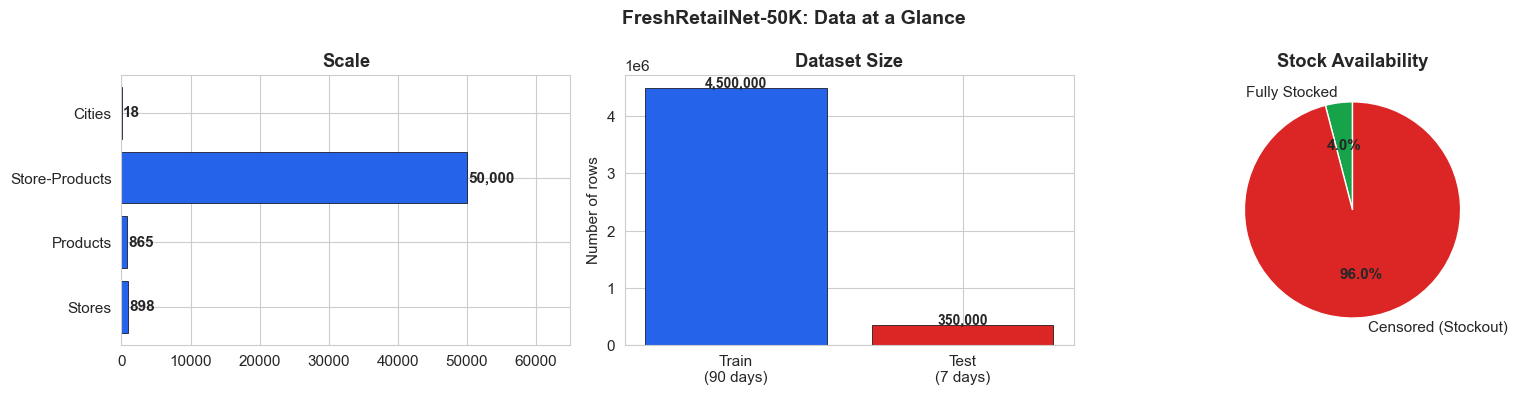

Censoring rate: 96.0% of training observations experienced stockouts


In [3]:
# Create a visual data overview
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('FreshRetailNet-50K: Data at a Glance', fontsize=14, fontweight='bold')

# Panel 1: Scale
scale_data = {
    'Stores': train_raw['store_id'].nunique(),
    'Products': train_raw['product_id'].nunique(),
    'Store-Products': train_raw['sp'].nunique(),
    'Cities': train_raw['city_id'].nunique(),
}
ax = axes[0]
bars = ax.barh(list(scale_data.keys()), list(scale_data.values()), color='#2563EB', edgecolor='black', lw=0.5)
for bar, val in zip(bars, scale_data.values()):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2, f'{val:,}', va='center', fontweight='bold')
ax.set_title('Scale', fontweight='bold')
ax.set_xlim(0, max(scale_data.values()) * 1.3)

# Panel 2: Time
ax = axes[1]
train_days = train_raw['dt'].nunique()
eval_days = eval_raw['dt'].nunique()
bars = ax.bar(['Train\n(90 days)', 'Test\n(7 days)'], [train_raw.shape[0], eval_raw.shape[0]],
              color=['#2563EB', '#DC2626'], edgecolor='black', lw=0.5)
for bar, val in zip(bars, [train_raw.shape[0], eval_raw.shape[0]]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10000,
            f'{val:,.0f}', ha='center', fontweight='bold', fontsize=10)
ax.set_ylabel('Number of rows')
ax.set_title('Dataset Size', fontweight='bold')

# Panel 3: Censoring
fully_stocked = (train_raw['stock_hour6_22_cnt'] == 16).sum()
censored = (train_raw['stock_hour6_22_cnt'] < 16).sum()
ax = axes[2]
wedges, texts, autotexts = ax.pie(
    [fully_stocked, censored],
    labels=['Fully Stocked', 'Censored (Stockout)'],
    colors=['#16A34A', '#DC2626'],
    autopct='%1.1f%%', startangle=90,
    textprops={'fontsize': 11}
)
autotexts[0].set_fontweight('bold')
autotexts[1].set_fontweight('bold')
ax.set_title('Stock Availability', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(NB_OUT, 'nb00_data_overview.png'), dpi=100, bbox_inches='tight')
plt.show()
print(f"Censoring rate: {censored / len(train_raw):.1%} of training observations experienced stockouts")

---
## Section 3: Sales ≠ Demand — The Censoring Problem

This is the single most important concept in this entire project. If you understand nothing else, understand this:

> **Observed sales are NOT the same as true demand.**

### The Fundamental Equation

$$\text{Observed Sales} = \min(\text{True Demand}, \text{Available Supply})$$

When a product is in stock all day (`stock_hour6_22_cnt = 16`), customers can buy as much as they want. In this case, Sales = Demand — the observation is **clean**.

When a product runs out during the day (`stock_hour6_22_cnt < 16`), some customers arrive after the stockout and leave empty-handed. Their demand is **real** but **unobserved**. The recorded sales figure is a **lower bound** on true demand — the observation is **censored**.

### Why This Matters

In our dataset, **~44% of all observations are censored**. This is not a minor data quality issue — it's a fundamental corruption of nearly half our training signal.

If we ignore censoring and train on raw `sale_amount`:
- The model learns that "this product sells 3 kg/day" when the truth is "this product sells 3 kg in 8 hours — full-day demand is probably 5–6 kg"
- The model under-predicts → the store orders less → more stockouts occur → sales drop further → the model learns even lower demand

This is called the **vicious cycle of censored demand**, and it is one of the costliest mistakes in retail analytics.

In [4]:
# Show real censoring examples from the data
sample_sp = train_raw.groupby('sp').size().sort_values(ascending=False).index[0]
sp_data = train_raw[train_raw['sp'] == sample_sp].sort_values('dt').head(14)

print("Example: 14 days of data for one store-product")
print("=" * 85)
print(f"{'Date':>12}  {'Sales (kg)':>12}  {'Stock Hours':>13}  {'Status':>20}")
print("-" * 85)
for _, row in sp_data.iterrows():
    status = "✓ Clean (full stock)" if row['stock_hour6_22_cnt'] == 16 else f"⚠ CENSORED ({row['stock_hour6_22_cnt']:.0f}h / 16h)"
    print(f"{str(row['dt'])[:10]:>12}  {row['sale_amount']:>12.2f}  {row['stock_hour6_22_cnt']:>13.0f}  {status:>20}")

censored_rows = sp_data[sp_data['stock_hour6_22_cnt'] < 16]
clean_rows = sp_data[sp_data['stock_hour6_22_cnt'] == 16]
if len(censored_rows) > 0 and len(clean_rows) > 0:
    print(f"\nAvg sales on CLEAN days:    {clean_rows['sale_amount'].mean():.2f} kg")
    print(f"Avg sales on CENSORED days: {censored_rows['sale_amount'].mean():.2f} kg")
    print(f"\n→ Censored days show {clean_rows['sale_amount'].mean() / max(censored_rows['sale_amount'].mean(), 0.01):.1f}x LOWER sales than clean days.")
    print("  But the true demand on censored days could be HIGHER than clean days!")

Example: 14 days of data for one store-product
        Date    Sales (kg)    Stock Hours                Status
-------------------------------------------------------------------------------------
  2024-03-28          0.50             13  ⚠ CENSORED (13h / 16h)
  2024-03-29          1.30              5  ⚠ CENSORED (5h / 16h)
  2024-03-30          5.30              0  ⚠ CENSORED (0h / 16h)
  2024-03-31          4.20              0  ⚠ CENSORED (0h / 16h)
  2024-04-01          0.70              0  ⚠ CENSORED (0h / 16h)
  2024-04-02          2.30              0  ⚠ CENSORED (0h / 16h)
  2024-04-03          1.30              5  ⚠ CENSORED (5h / 16h)
  2024-04-04          4.70              0  ⚠ CENSORED (0h / 16h)
  2024-04-05          3.10              1  ⚠ CENSORED (1h / 16h)
  2024-04-06          5.50              3  ⚠ CENSORED (3h / 16h)
  2024-04-07          1.50              6  ⚠ CENSORED (6h / 16h)
  2024-04-08          1.90              0  ⚠ CENSORED (0h / 16h)
  2024-04-09          

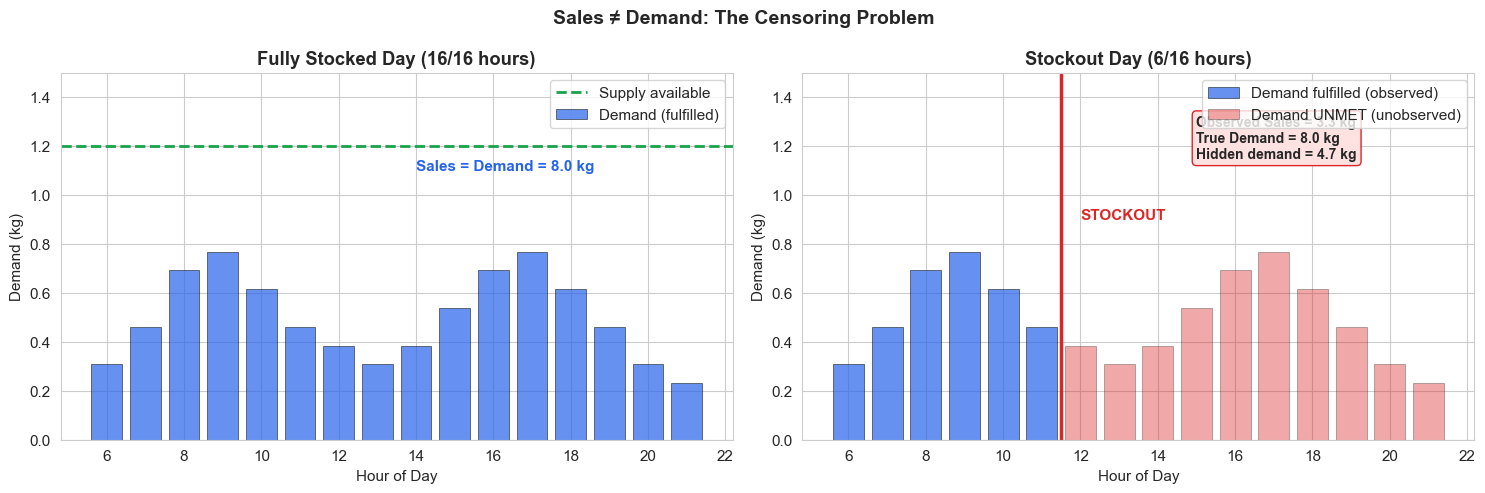

In [5]:
# Conceptual diagram: Sales vs Demand under censoring
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Sales ≠ Demand: The Censoring Problem', fontsize=14, fontweight='bold')

# Panel 1: Fully stocked day
ax = axes[0]
hours = np.arange(6, 22)
demand_profile = np.array([0.4, 0.6, 0.9, 1.0, 0.8, 0.6, 0.5, 0.4, 0.5, 0.7, 0.9, 1.0, 0.8, 0.6, 0.4, 0.3])
demand_profile = demand_profile / demand_profile.sum() * 8  # total 8 kg demand

ax.bar(hours, demand_profile, color='#2563EB', alpha=0.7, label='Demand (fulfilled)', edgecolor='black', lw=0.5)
ax.axhline(y=1.2, color='#16A34A', ls='--', lw=2, label='Supply available')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Demand (kg)')
ax.set_title('Fully Stocked Day (16/16 hours)', fontweight='bold')
ax.legend(loc='upper right')
ax.set_ylim(0, 1.5)
ax.annotate('Sales = Demand = 8.0 kg', xy=(14, 1.1), fontsize=11, fontweight='bold', color='#2563EB')

# Panel 2: Stockout day
ax = axes[1]
stockout_hour = 12  # runs out at noon (6 hours of stock)
fulfilled = demand_profile.copy()
unfulfilled = demand_profile.copy()
for i, h in enumerate(hours):
    if h >= stockout_hour:
        fulfilled[i] = 0
    else:
        unfulfilled[i] = 0

ax.bar(hours, fulfilled, color='#2563EB', alpha=0.7, label='Demand fulfilled (observed)', edgecolor='black', lw=0.5)
ax.bar(hours, unfulfilled, color='#DC2626', alpha=0.4, label='Demand UNMET (unobserved)', edgecolor='black', lw=0.5)
ax.axvline(x=stockout_hour - 0.5, color='#DC2626', ls='-', lw=2.5)
ax.annotate('STOCKOUT', xy=(stockout_hour, 0.9), fontsize=11, fontweight='bold', color='#DC2626')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Demand (kg)')
ax.set_title('Stockout Day (6/16 hours)', fontweight='bold')
ax.legend(loc='upper right')
ax.set_ylim(0, 1.5)

observed_sales = fulfilled.sum()
true_demand = demand_profile.sum()
ax.annotate(f'Observed Sales = {observed_sales:.1f} kg\nTrue Demand = {true_demand:.1f} kg\nHidden demand = {true_demand - observed_sales:.1f} kg',
            xy=(15, 1.15), fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#FEE2E2', edgecolor='#DC2626'))

plt.tight_layout()
plt.savefig(os.path.join(NB_OUT, 'nb00_sales_vs_demand_concept.png'), dpi=100, bbox_inches='tight')
plt.show()

### The Vicious Cycle

If you train a model on censored sales without correction:

```
Stockout occurs → Recorded sales DROP (censored)
         ↓
Model trains on low sales → Predicts LOW demand
         ↓
Low forecast → Store orders LESS inventory
         ↓
Less inventory → MORE stockouts
         ↓
(Cycle repeats — demand estimates keep SHRINKING)
```

**Breaking the cycle** requires explicitly accounting for censoring. Our pipeline does this in two ways:

1. **Demand recovery features**: We estimate what true demand *would have been* on censored days (using Tobit/IMR correction) and feed this as an input feature to the model (see NB 01).

2. **Censored weighting**: We downweight censored observations (0.5× weight) during model training, so the model trusts fully-stocked days more (see NB 03).

> **The target variable remains `sale_amount`** (observed sales). We do NOT replace it with recovered demand. The recovery estimate is too noisy to serve as the target — but it is informative enough to serve as a feature.

---
## Section 4: Train vs. Test — What Do We Actually Know?

### The Data We Have

| Aspect | Training Set (90 days) | Test Set (7 days) |
|--------|----------------------|-------------------|
| **Period** | Mar 28 – Jun 25, 2024 | Jun 26 – Jul 2, 2024 |
| **What we observe** | `sale_amount` + `stock_hour6_22_cnt` | `sale_amount` + `stock_hour6_22_cnt` |
| **Censoring rate** | ~44% of rows | Similar rate (verified below) |
| **True demand** | ❌ **Unknown** | ❌ **Unknown** |
| **Used for** | Training the model | Evaluating the model + simulating inventory policies |

### The Critical Insight

> **We do not have ground truth demand in the test set.**
>
> The `sale_amount` in the test set is **also censored by stockouts**. When we "evaluate" our inventory policies by computing profit = Revenue − Cost against the test set, we are comparing our order quantity $Q$ against **observed sales** $D_{obs}$, not against **true demand** $D_{true}$.

This means **every metric we report is optimistically biased**:

| Metric | Bias Direction | Why |
|--------|---------------|-----|
| **Profit** | Overestimated ↑ | True stockout costs are higher than measured |
| **Service Level** | Overestimated ↑ | We think demand was met when it was actually censored |
| **Fill Rate** | Overestimated ↑ | True demand denominator is larger |
| **Stockout Rate** | Underestimated ↓ | We miss stockouts where both $Q$ and $D_{obs}$ are low |

### A Concrete Example

Suppose on a test day:
- **True demand** = 8 kg (unknown to us)
- **Product stocked out** after selling 5 kg → **Observed** `sale_amount` = 5 kg
- **Our policy orders** Q = 6 kg

**What we compute:**
- Revenue = min(6, 5) × \$1.0 = \$5.00
- Stockout cost = max(5 − 6, 0) × \$0.50 = \$0.00 ← We think there's no stockout!

**What actually happened:**
- Revenue = min(6, 8) × \$1.0 = \$6.00
- Stockout cost = max(8 − 6, 0) × \$0.50 = \$1.00 ← 2 kg of demand went unmet

The evaluation tells us "no stockout, high profit" when in reality 25% of demand was unmet. This bias exists for **every censored observation** in the test set.

In [6]:
# Verify that the test set is also censored
train_cens_rate = (train_raw['stock_hour6_22_cnt'] < 16).mean()
eval_cens_rate  = (eval_raw['stock_hour6_22_cnt'] < 16).mean()

print("Censoring rates:")
print(f"  Training set:   {train_cens_rate:.1%}  ({(train_raw['stock_hour6_22_cnt'] < 16).sum():,} of {len(train_raw):,} rows)")
print(f"  Evaluation set: {eval_cens_rate:.1%}  ({(eval_raw['stock_hour6_22_cnt'] < 16).sum():,} of {len(eval_raw):,} rows)")
print(f"\n→ Both periods have similar censoring rates.")
print(f"→ The test set is NOT 'clean' ground truth — it has the same censoring problem as training.")
print(f"\n⚠️  Every metric computed on the test set is optimistically biased.")
print(f"    The +79% profit improvement we report is a DIRECTIONAL estimate, not an exact number.")

Censoring rates:
  Training set:   96.0%  (4,318,209 of 4,500,000 rows)
  Evaluation set: 96.4%  (337,459 of 350,000 rows)

→ Both periods have similar censoring rates.
→ The test set is NOT 'clean' ground truth — it has the same censoring problem as training.

⚠️  Every metric computed on the test set is optimistically biased.
    The +79% profit improvement we report is a DIRECTIONAL estimate, not an exact number.


---
## Section 5: Modeling the Forecasting Problem

### Objective

> Predict `sale_amount` (kg) for each store-product for each of the next 7 days.

This is a **supervised regression** problem where:
- **Unit of prediction**: one (store, product, day) combination
- **Target**: `sale_amount` (continuous, non-negative, censored)
- **Features**: everything else we know about that SP on that day

### What Features Do We Need?

| Feature Group | Business Rationale | Source Columns | Example Feature |
|---------------|-------------------|---------------|-----------------|
| **Temporal** | Demand has weekly/monthly patterns | `dt` | `day_of_week_sin`, `day_of_week_cos`, `is_weekend` |
| **Lag features** | Yesterday's sales predict today's | `sale_amount` (past) | `lag_1`, `lag_7`, `lag_14` |
| **Rolling stats** | Recent trend matters | `sale_amount` (past) | `rolling_mean_7d`, `rolling_std_7d` |
| **EWMA** | Smoothed trend, weights recent more | `sale_amount` (past) | `ewma_7d`, `ewma_14d` |
| **Stockout features** | Censoring history affects demand | `stock_hour6_22_cnt` | `stockout_rate_7d`, `yesterday_stockout` |
| **Recovered demand** | Uncensored estimate of true demand | `sale_amount` + `stock_hour6_22_cnt` | `recovered_lag_1`, `recovered_rolling_7d` |
| **Promotions** | Discounts/holidays create demand spikes | `discount`, `holiday_flag`, `activity_flag` | Direct columns + interactions |
| **Weather** | Temperature affects perishable demand | `avg_temperature`, `precpt`, etc. | Direct columns |
| **Hierarchy** | Category/store patterns add signal | `category_id`, `store_id`, `city_id` | `category_mean`, `store_volume`, `sp_vs_category_ratio` |
| **Clustering** | Demand archetypes share patterns | Behavioral profiles | `cluster_id`, `cluster_mean` |

> **Total: ~120 features from 17 raw columns.** Feature engineering is the highest-ROI step in the pipeline. See NB 02 for the full implementation.

### Why Tabular ML (LightGBM), Not Time-Series Models?

| Factor | Tabular ML (LightGBM) | Time-Series (ARIMA/Prophet) |
|--------|----------------------|---------------------------|
| **50,000 heterogeneous SPs** | One model handles all SPs via features | Must fit separate model per SP |
| **Rich feature set (120+)** | Natively handles many features | Limited to regressors |
| **Category/store hierarchy** | Natural as features | No built-in support |
| **Censoring indicators** | Easy to include as features + sample weights | No natural mechanism |
| **Training speed** | ~3 min for 500K rows | Hours for 50K separate models |
| **Intermittent demand** | Handles via features (zero-rate, etc.) | Requires special methods (Croston) |

LightGBM is not the only option, but it is the pragmatic choice for this problem structure: many entities, rich features, mixed data types, fast iteration.

### The Role of Demand Recovery in Forecasting

A common question: *"If we recover true demand, why not use it as the prediction target?"*

**Answer**: The recovery estimate is too noisy. The Tobit correction adds statistical estimation error that would corrupt the target. Instead, we use it as an **input feature**:

```
Target:    sale_amount (observed, censored)     ← what the model predicts
Feature:   demand_recovered (Tobit-corrected)   ← helps the model understand true demand patterns
Feature:   stock_hour6_22_cnt                   ← tells the model which observations are censored
Weight:    0.5 for censored observations        ← tells the model to trust clean days more
```

This hybrid approach gives the model access to our best estimate of true demand without corrupting the target.

### Temporal Validation: Why You Must Never Shuffle Time Series

In standard ML (image classification, tabular prediction), random train/test splits are fine. In time-series forecasting, they are **catastrophic**:

| Approach | What Happens | Result |
|----------|-------------|--------|
| ❌ Random split | Model sees future data during training | **Data leakage** — inflated metrics |
| ❌ Single temporal split | Model evaluated on one week only | **Fragile** — MAE varies 10–15% by week |
| ✅ Temporal CV (expanding window) | Multiple forward-looking splits | **Robust** — mean ± std across folds |

Our pipeline uses **4-fold expanding-window cross-validation**, where each fold trains on all past data and validates on the next 7 days. This:
1. Prevents data leakage (never trains on future data)
2. Provides confidence intervals (mean ± std across folds)
3. Simulates real deployment (model retrained on growing history)

> See NB 03 for the full implementation and fold-by-fold results.

---
## Section 6: Modeling the Optimization Problem

### From Forecast to Decision

A forecast tells you: *"Expected demand is 5 kg."*

But should you order 5 kg? Consider:
- If you order 5 and demand is 4 → 1 kg wasted (cost: \$0.70)
- If you order 5 and demand is 6 → 1 kg stockout (cost: \$0.50 + lost goodwill)
- If you order 5 and demand is 5 → perfect (rare in practice!)

The optimal order depends on the **relative cost of being wrong in each direction**.

### The Newsvendor Framework

The Newsvendor model is the foundational framework for this decision. It says:

$$Q^* = F^{-1}(\text{CR})$$

where:
- $Q^*$ is the **optimal order quantity**
- $F^{-1}$ is the **inverse CDF of the demand distribution** (the quantile function)
- $\text{CR}$ is the **Critical Ratio**: the optimal service level

$$\text{CR} = \frac{C_u}{C_u + C_o}$$

where $C_u$ is the cost of **under-ordering** (lost margin per kg of unmet demand) and $C_o$ is the cost of **over-ordering** (waste cost per kg of unsold product).

### What the Critical Ratio Tells You

| CR Value | Meaning | Strategy |
|----------|---------|----------|
| CR < 0.5 | Waste is more expensive than stockouts | **Order conservatively** (below the median) |
| CR = 0.5 | Costs are symmetric | Order the **median** demand |
| CR > 0.5 | Stockouts are more expensive than waste | **Order aggressively** (above the median) |

> **In plain English**: The Critical Ratio tells you what *percentile* of the demand distribution to order. CR = 0.7 means "order enough to cover 70% of possible demand scenarios."

### The Cost Parameters You Must Get Right

| Parameter | Symbol | Business Meaning | Who Provides This? | If Wrong... |
|-----------|--------|-----------------|--------------------|----|
| Unit revenue | $p$ | Selling price per kg | Finance / Pricing | CR shifts; orders are miscalibrated |
| Unit cost | $c$ | Purchase cost per kg | Procurement | Profit is miscalculated |
| Holding cost | $h$ | Refrigeration, storage per kg/day | Operations | Over-ordering is under-penalized |
| Stockout penalty | $p_s$ | Lost goodwill per kg unmet | Marketing / Strategy | The hardest to estimate; drives CR heavily |
| Waste cost | $w$ | Disposal cost per kg spoiled | Operations | Over-ordering is under-penalized |

> ⚠️ **The stockout penalty is the most important and hardest-to-estimate parameter.** It's not just the lost margin — it includes the lifetime value of a customer who switches to a competitor. Getting this wrong by 2× can shift the optimal policy from "lean ordering" to "aggressive stocking." See NB 05 for a sensitivity analysis.

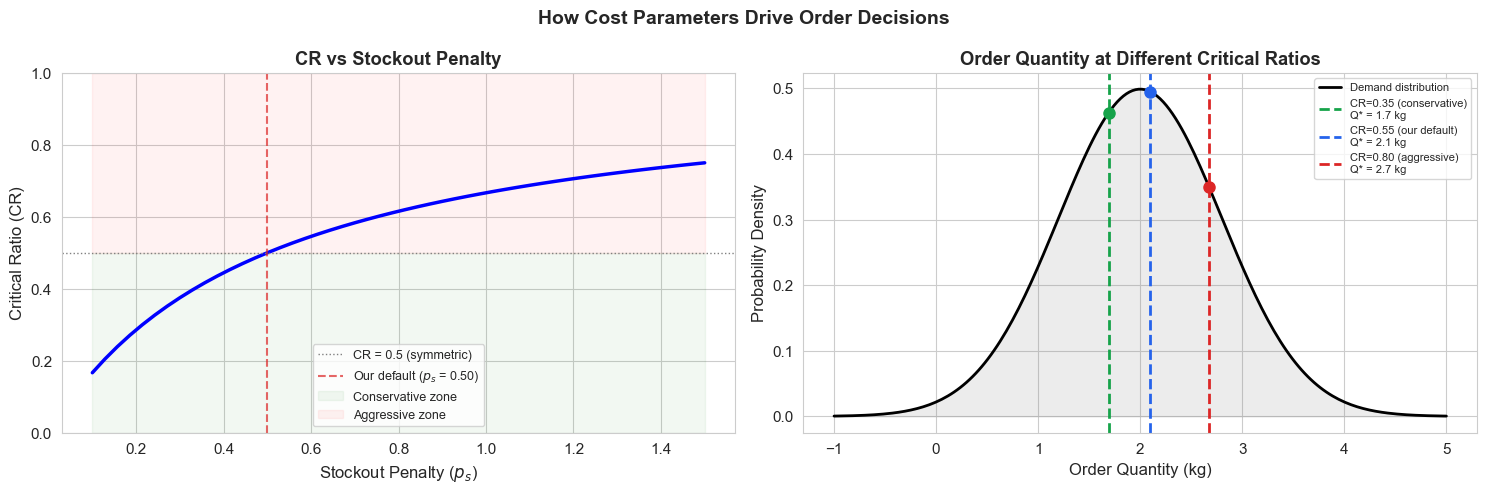

Key insight: A small change in the stockout penalty shifts the optimal order quantity significantly.
Before deploying ANY inventory policy, you must calibrate your cost parameters with Finance and Operations.


In [7]:
# Illustrate how the Critical Ratio shifts order quantities
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('How Cost Parameters Drive Order Decisions', fontsize=14, fontweight='bold')

# Panel 1: CR as a function of stockout penalty
p_values = np.linspace(0.1, 1.5, 50)
unit_cost = 0.4
waste_cost = 0.3
holding = 0.1
CRs = (1.0 - unit_cost) / ((1.0 - unit_cost) + (unit_cost + holding))  # base
CRs_varying = p_values / (p_values + (unit_cost + holding))

ax = axes[0]
ax.plot(p_values, CRs_varying, 'b-', lw=2.5)
ax.axhline(0.5, color='gray', ls=':', lw=1, label='CR = 0.5 (symmetric)')
ax.axvline(0.5, color='#DC2626', ls='--', lw=1.5, alpha=0.7, label='Our default ($p_s$ = 0.50)')
ax.fill_between(p_values, 0, 0.5, alpha=0.05, color='green', label='Conservative zone')
ax.fill_between(p_values, 0.5, 1.0, alpha=0.05, color='red', label='Aggressive zone')
ax.set_xlabel('Stockout Penalty ($p_s$)', fontsize=12)
ax.set_ylabel('Critical Ratio (CR)', fontsize=12)
ax.set_title('CR vs Stockout Penalty', fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim(0, 1)

# Panel 2: What CR means for order quantity (Normal demand example)
from scipy import stats
ax = axes[1]
x = np.linspace(-1, 5, 200)
mu, sigma = 2.0, 0.8
pdf = stats.norm.pdf(x, mu, sigma)
ax.plot(x, pdf, 'k-', lw=2, label='Demand distribution')
ax.fill_between(x, pdf, alpha=0.15, color='gray')

# Show different CR quantiles
for cr, color, label in [(0.35, '#16A34A', 'CR=0.35 (conservative)'),
                          (0.55, '#2563EB', 'CR=0.55 (our default)'),
                          (0.80, '#DC2626', 'CR=0.80 (aggressive)')]:
    q = stats.norm.ppf(cr, mu, sigma)
    ax.axvline(q, color=color, ls='--', lw=2, label=f'{label}\nQ* = {q:.1f} kg')
    ax.plot(q, stats.norm.pdf(q, mu, sigma), 'o', color=color, ms=8, zorder=5)

ax.set_xlabel('Order Quantity (kg)', fontsize=12)
ax.set_ylabel('Probability Density', fontsize=12)
ax.set_title('Order Quantity at Different Critical Ratios', fontweight='bold')
ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig(os.path.join(NB_OUT, 'nb00_critical_ratio_illustration.png'), dpi=100, bbox_inches='tight')
plt.show()

print("Key insight: A small change in the stockout penalty shifts the optimal order quantity significantly.")
print("Before deploying ANY inventory policy, you must calibrate your cost parameters with Finance and Operations.")

### Why You Need the Distribution, Not Just the Point Forecast

The Newsvendor formula requires $F^{-1}(\text{CR})$ — the **quantile** of the demand distribution. A point forecast gives you the mean or median, but not the full shape.

Two approaches:

| Approach | Assumes | Pros | Cons |
|----------|---------|------|------|
| **Normal-based** | $D \sim \mathcal{N}(\hat{\mu}, \hat{\sigma}^2)$ | Simple; well-understood | Fails for zero-inflated, skewed demand |
| **Non-parametric** | No distributional assumption | Captures true demand shape | Needs sufficient historical data per SP |

Fresh retail demand is typically **not Normal** — it has:
- Zero-inflation (many days with zero sales)
- Right skew (occasional high-demand spikes)
- Discrete-like clustering (sales often at round values)

Non-parametric policies (like the Empirical Newsvendor) that use the *actual* demand distribution outperform Normal-based policies in our experiments. See NB 05 for the full comparison.

---
## Section 7: Where to Focus Your Modeling Effort

### Not All Products Deserve ML

A common mistake is building one sophisticated model and applying it uniformly to all 50,000 store-products. In reality:
- **A-class items** (top 20% of items, ~80% of revenue) benefit enormously from accurate forecasting and optimized ordering.
- **C-class items** (bottom 50% of items, ~5% of revenue) often have such low and erratic demand that ML adds no value over simple rules.

### The ABC-XYZ Framework

Before building any model, classify your product catalog:

| | **X (Predictable)** CV ≤ 0.5 | **Y (Variable)** 0.5 < CV ≤ 1.0 | **Z (Erratic)** CV > 1.0 |
|---|---|---|---|
| **A (High Volume)** | 🟢 ML + tight safety stock | 🟡 ML + moderate buffer | 🟠 ML + generous buffer |
| **B (Medium Volume)** | 🟢 Simple rules may suffice | 🟡 ML recommended | 🟠 ML + safety buffer |
| **C (Low Volume)** | ⚪ Automate with min/max rules | ⚪ Periodic review | 🔴 Order on demand or delist |

Where:
- **ABC** = ranked by demand volume contribution (Pareto principle)
- **XYZ** = ranked by coefficient of variation (demand predictability)
- **CV** = standard deviation / mean (lower = more predictable)

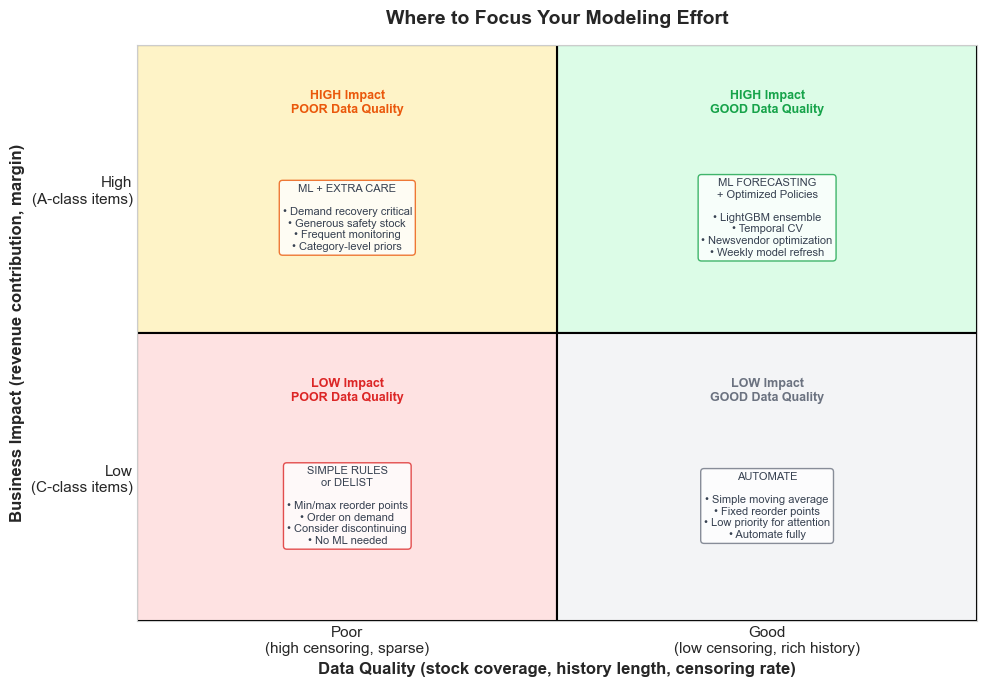

In [8]:
# Effort allocation matrix
fig, ax = plt.subplots(figsize=(10, 7))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)

# Quadrants
colors = ['#DCFCE7', '#FEF3C7', '#FEE2E2', '#F3F4F6']
labels_q = [
    ('HIGH Impact\nGOOD Data Quality', 'ML FORECASTING\n+ Optimized Policies\n\n• LightGBM ensemble\n• Temporal CV\n• Newsvendor optimization\n• Weekly model refresh', '#16A34A'),
    ('HIGH Impact\nPOOR Data Quality', 'ML + EXTRA CARE\n\n• Demand recovery critical\n• Generous safety stock\n• Frequent monitoring\n• Category-level priors', '#EA580C'),
    ('LOW Impact\nPOOR Data Quality', 'SIMPLE RULES\nor DELIST\n\n• Min/max reorder points\n• Order on demand\n• Consider discontinuing\n• No ML needed', '#DC2626'),
    ('LOW Impact\nGOOD Data Quality', 'AUTOMATE\n\n• Simple moving average\n• Fixed reorder points\n• Low priority for attention\n• Automate fully', '#6B7280'),
]

positions = [(5, 7.5, 7.5, 5), (5, 7.5, 2.5, 5), (5, 2.5, 2.5, 5), (5, 2.5, 7.5, 5)]
for i, ((w, h, cx, cy), (qlabel, strategy, color)) in enumerate(zip(
    [(5, 5, 7.5, 7.5), (5, 5, 2.5, 7.5), (5, 5, 2.5, 2.5), (5, 5, 7.5, 2.5)],
    labels_q)):
    rect = plt.Rectangle((cx - w/2, cy - h/2), w, h, facecolor=colors[i], edgecolor='black', lw=1.5)
    ax.add_patch(rect)
    ax.text(cx, cy + 1.5, qlabel, ha='center', va='center', fontsize=9, fontweight='bold', color=color)
    ax.text(cx, cy - 0.5, strategy, ha='center', va='center', fontsize=8, color='#374151',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=color, alpha=0.8))

ax.set_xlabel('Data Quality (stock coverage, history length, censoring rate)', fontsize=12, fontweight='bold')
ax.set_ylabel('Business Impact (revenue contribution, margin)', fontsize=12, fontweight='bold')
ax.set_title('Where to Focus Your Modeling Effort', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks([2.5, 7.5])
ax.set_xticklabels(['Poor\n(high censoring, sparse)', 'Good\n(low censoring, rich history)'])
ax.set_yticks([2.5, 7.5])
ax.set_yticklabels(['Low\n(C-class items)', 'High\n(A-class items)'])
ax.tick_params(length=0)

plt.tight_layout()
plt.savefig(os.path.join(NB_OUT, 'nb00_effort_allocation.png'), dpi=100, bbox_inches='tight')
plt.show()

---
## Section 8: How to Validate Forecasting

### Choosing the Right Metric

| Metric | Formula | Best For | Pitfall |
|--------|---------|----------|---------|
| **MAE** | $\frac{1}{n}\sum|y - \hat{y}|$ | General accuracy | Treats all items equally |
| **RMSE** | $\sqrt{\frac{1}{n}\sum(y - \hat{y})^2}$ | Penalizing large errors | Sensitive to outliers |
| **SMAPE** | $\frac{100}{n}\sum\frac{|y-\hat{y}|}{(|y|+|\hat{y}|)/2}$ | Percentage accuracy | ⚠️ **Inflates low-volume errors** |
| **WMAE** | $\frac{\sum|y-\hat{y}|\cdot y}{\sum y}$ | **Economic impact** | Ignores low-volume items |

### The SMAPE Trap

SMAPE treats a 0.05 kg error on a product selling 0.1 kg/day **the same** as a 0.5 kg error on a product selling 10 kg/day. But economically, the 0.5 kg error matters **100× more** (10× higher volume × 10× more absolute error).

> **Recommendation**: Use **WMAE** as the primary metric for retail demand forecasting. It aligns the metric with economic impact — errors on high-volume products count more.

In [9]:
# Toy example: SMAPE vs WMAE
print("SMAPE vs WMAE: A Toy Example")
print("=" * 65)
print(f"{'Product':>10} {'Actual':>8} {'Forecast':>10} {'Error':>8} {'SMAPE':>8} {'Wt.Err':>8}")
print("-" * 65)

products = [
    ('Herbs',     0.1, 0.15, ),
    ('Tofu',      1.0, 0.9,  ),
    ('Chicken',  10.0, 9.0,  ),
]

total_smape = 0
total_weighted_err = 0
total_actual = 0

for name, actual, forecast in products:
    error = abs(actual - forecast)
    smape = 200 * error / (actual + forecast)  # single-obs SMAPE
    weighted_err = error * actual
    total_smape += smape
    total_weighted_err += weighted_err
    total_actual += actual
    print(f'{name:>10} {actual:>8.1f} {forecast:>10.1f} {error:>8.2f} {smape:>7.1f}% {weighted_err:>8.2f}')

avg_smape = total_smape / 3
wmae = total_weighted_err / total_actual

print("-" * 65)
print(f"{'Average':>10} {'':>8} {'':>10} {'':>8} {avg_smape:>7.1f}% {wmae:>8.3f}")
print()
print(f"SMAPE says: Herbs (33.3%) and Chicken (5.3%) — Herbs looks terrible!")
print(f"WMAE says:  Chicken contributes 90% of weighted error — focus there!")
print(f"\n→ SMAPE would make you optimize for herbs (0.1 kg/day).")
print(f"→ WMAE correctly focuses on chicken (10 kg/day, 90% of revenue).")

SMAPE vs WMAE: A Toy Example
   Product   Actual   Forecast    Error    SMAPE   Wt.Err
-----------------------------------------------------------------
     Herbs      0.1        0.1     0.05    40.0%     0.00
      Tofu      1.0        0.9     0.10    10.5%     0.10
   Chicken     10.0        9.0     1.00    10.5%    10.00
-----------------------------------------------------------------
   Average                                 20.4%    0.910

SMAPE says: Herbs (33.3%) and Chicken (5.3%) — Herbs looks terrible!
WMAE says:  Chicken contributes 90% of weighted error — focus there!

→ SMAPE would make you optimize for herbs (0.1 kg/day).
→ WMAE correctly focuses on chicken (10 kg/day, 90% of revenue).


---
## Section 9: How to Validate Optimization — The Hard Problem

This is the **most important section** of this notebook. Most tutorials on inventory optimization silently assume that the test set contains ground truth demand. It does not.

### The Problem (Revisited)

When we simulate an inventory policy on the test set, we compute:

$$\text{Profit} = \min(Q, D) \times p - Q \times c - Q \times h - \max(D-Q, 0) \times p_s - \max(Q-D, 0) \times w$$

But **$D$ is observed sales, not true demand**. Every time the test set contains a stockout ($D < D_{true}$), we:
1. **Undercount stockouts**: We think $Q \geq D$ (no stockout) when actually $Q < D_{true}$ (real stockout)
2. **Overcount waste**: We think $Q - D$ is waste, but some of that "waste" would have been sold
3. **Overestimate profit**: We miss the stockout cost that should have been charged

> **The more censoring in the test set, the more optimistic our results.**

### Five Approaches to Validate Optimization (Ranked by Reliability)

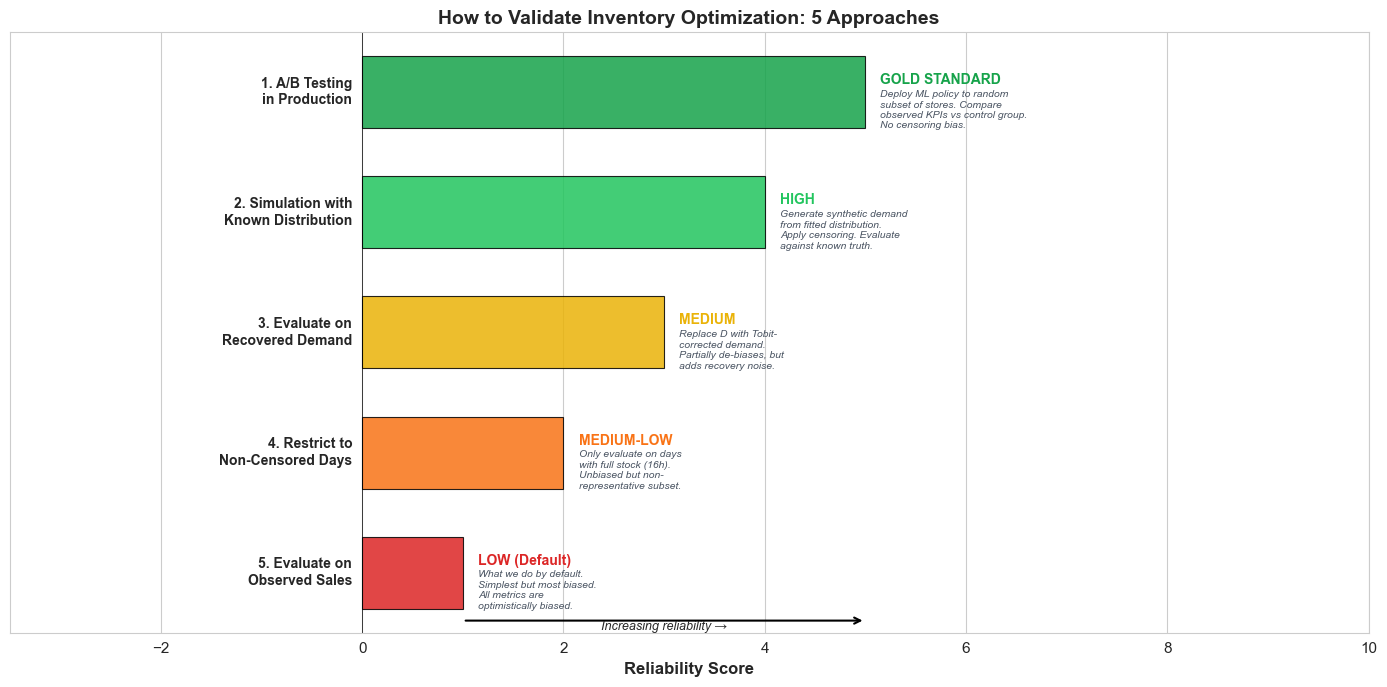

In [10]:
# Validation approaches comparison
fig, ax = plt.subplots(figsize=(14, 7))

approaches = [
    ('1. A/B Testing\nin Production', 'GOLD STANDARD', 5, '#16A34A',
     'Deploy ML policy to random\nsubset of stores. Compare\nobserved KPIs vs control group.\nNo censoring bias.'),
    ('2. Simulation with\nKnown Distribution', 'HIGH', 4, '#22C55E',
     'Generate synthetic demand\nfrom fitted distribution.\nApply censoring. Evaluate\nagainst known truth.'),
    ('3. Evaluate on\nRecovered Demand', 'MEDIUM', 3, '#EAB308',
     'Replace D with Tobit-\ncorrected demand.\nPartially de-biases, but\nadds recovery noise.'),
    ('4. Restrict to\nNon-Censored Days', 'MEDIUM-LOW', 2, '#F97316',
     'Only evaluate on days\nwith full stock (16h).\nUnbiased but non-\nrepresentative subset.'),
    ('5. Evaluate on\nObserved Sales', 'LOW (Default)', 1, '#DC2626',
     'What we do by default.\nSimplest but most biased.\nAll metrics are\noptimistically biased.'),
]

for i, (name, reliability, score, color, description) in enumerate(approaches):
    y = len(approaches) - i - 1
    # Bar
    bar = ax.barh(y, score, height=0.6, color=color, edgecolor='black', lw=0.8, alpha=0.85)
    # Label
    ax.text(-0.1, y, name, ha='right', va='center', fontsize=10, fontweight='bold')
    # Reliability label
    ax.text(score + 0.15, y + 0.1, reliability, ha='left', va='center', fontsize=10,
            fontweight='bold', color=color)
    # Description
    ax.text(score + 0.15, y - 0.15, description, ha='left', va='center', fontsize=7.5,
            color='#4B5563', style='italic')

ax.set_xlim(-3.5, 10)
ax.set_ylim(-0.5, len(approaches) - 0.5)
ax.set_xlabel('Reliability Score', fontsize=12, fontweight='bold')
ax.set_title('How to Validate Inventory Optimization: 5 Approaches', fontsize=14, fontweight='bold')
ax.set_yticks([])
ax.axvline(0, color='black', lw=0.5)

# Arrow annotation
ax.annotate('', xy=(5, -0.4), xytext=(1, -0.4),
            arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
ax.text(3, -0.48, 'Increasing reliability →', ha='center', fontsize=9, style='italic')

plt.tight_layout()
plt.savefig(os.path.join(NB_OUT, 'nb00_validation_approaches.png'), dpi=100, bbox_inches='tight')
plt.show()

### When to Use Each Approach

| Approach | When to Use | Practical Notes |
|----------|-------------|-----------------|
| **A/B Testing** | Before production rollout | Requires infrastructure for randomized store assignment. Gold standard but expensive. |
| **Simulation** | During development | Build a demand simulator from fitted distributions. Useful for stress-testing policies. |
| **Recovered Demand** | As a sensitivity check | Run evaluation twice: once on observed sales, once on recovered. Report both. |
| **Non-Censored Only** | For "clean" estimates | Useful for understanding model behavior on uncensored data. Not representative of full catalog. |
| **Observed Sales** | Default / tutorial | Fine for comparing policies *relative* to each other. Absolute numbers are optimistic. |

### What to Tell Stakeholders

When presenting inventory optimization results:

1. **Always present relative improvements**, not absolute numbers. "ML + Optimization improves profit by ~79% over static rules" is more defensible than "profit per unit is \$0.286."

2. **Acknowledge the bias explicitly**: "These metrics are computed against observed sales, which understates true demand. Real-world improvement is likely to be in the same direction but the exact magnitude needs A/B validation."

3. **Use the Pareto frontier** to frame the discussion: "Here's the trade-off between profit and service level. Where do you want to be on this curve?" This shifts the conversation from "is the model accurate?" to "what business trade-off do we prefer?"

4. **Propose an A/B test** as the next step. This is the only way to get unbiased real-world numbers.

---
## Section 10: The Modeling Roadmap

### The Notebook Series

| Notebook | Title | Business Question | What You'll Learn |
|----------|-------|-------------------|-------------------|
| **00** (this) | Business Understanding & Modeling | How should we frame this problem? | Conceptual framework, data roles, limitations |
| **01** | Data Exploration & Censored Demand | What does our data look like? | Distributions, patterns, 3 recovery methods |
| **02** | Feature Engineering & Hierarchy | What inputs does the model need? | 120+ features, KMeans clustering, PCA |
| **03** | Forecasting Models & Validation | How do we train and validate? | Temporal CV, LightGBM ensemble, feature importance |
| **04** | Forecast Evaluation & Error Analysis | How good is the forecast? | SMAPE vs WMAE, segment analysis, PI calibration |
| **05** | Inventory Optimization & ABC-XYZ | How do we turn forecasts into orders? | 18 policies, Pareto frontier, sensitivity, before-vs-after |

### Checklist Before Starting a Forecasting & Optimization Project

**Data Requirements:**
- [ ] Daily sales data at the store-product level (minimum 60–90 days)
- [ ] Stock availability indicator (hours in stock, binary stockout flag, or similar)
- [ ] Product hierarchy (categories, at least 2 levels)
- [ ] Calendar features (day of week, holidays — often derivable from dates)
- [ ] Promotional/discount data (if available)
- [ ] Weather data (if relevant to category — always relevant for fresh/perishable)

**Business Requirements:**
- [ ] Cost parameters estimated with Finance: unit cost, revenue, waste cost, holding cost
- [ ] Stockout penalty agreed with Marketing/Strategy (the hardest parameter!)
- [ ] Target service level defined by Operations (e.g., 90%, 95%)
- [ ] Shelf life per product category from Operations
- [ ] Lead time (order-to-delivery) from Supply Chain

**Modeling Requirements:**
- [ ] Assess censoring rate — if > 20%, demand recovery is essential
- [ ] Run ABC-XYZ segmentation before building models — focus ML on A/B items
- [ ] Plan temporal cross-validation (not random splits!)
- [ ] Plan evaluation: which metrics, which baselines, how to report
- [ ] Plan A/B test design for production validation

### Key Takeaways

1. **Sales ≠ Demand**. With ~44% censoring, ignoring this corrupts your entire pipeline.

2. **The test set is also censored**. Every evaluation metric is optimistically biased. Report directional improvements, not absolute numbers.

3. **Feature engineering > model architecture**. 120 well-crafted features with LightGBM outperform fancy models with poor features.

4. **The forecast alone is not the answer**. Inventory optimization turns forecasts into decisions. Without it, you're just ordering the predicted mean — which is suboptimal.

5. **Cost parameters drive everything**. A 2× error in the stockout penalty changes the optimal policy from "lean" to "aggressive." Invest time in getting these right.

6. **Not all products need ML**. ABC-XYZ segmentation tells you where ML adds value and where simple rules suffice.

7. **Validate with A/B testing**. Offline metrics are directional. Real-world impact requires randomized controlled experiments.

---

*Continue to **Notebook 01** for hands-on data exploration and censored demand recovery →*